# London Airbnb Price Modeling Notebook

This notebook is organized into three clean sections:

1. **Part 1: Data Overview, Cleaning, EDA, and SQL**
2. **Part 2: Model Training (Version 1 to Version 6) and V4-V6 Comparison**
3. **Part 3: Model Export Artifacts**

The workflow is designed to be reproducible from top to bottom.

In [1]:
from pathlib import Path

import pandas as pd

# Disable scientific notation and format floats to two decimals
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Read the compressed data file from the current directory
file_path = Path("listings.csv.gz")
df = pd.read_csv(file_path, compression="gzip")

print(f"File path: {file_path.resolve()}")
print(f"Data shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nPreview of first 5 rows:")
display(df.head())

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
})

print("\nColumn overview (sorted by missing rate descending):")
display(overview.sort_values("missing_pct", ascending=False))

numeric_summary = df.describe().T
categorical_summary = df.describe(include="object").T

print("\nNumeric column statistics:")
display(numeric_summary)

print("\nCategorical column statistics:")
display(categorical_summary)

print("\nTop 15 columns by missing rate:")
display(overview.sort_values("missing_pct", ascending=False).head(15))

File path: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\listings.csv.gz
Data shape: 96,871 rows x 79 columns
Duplicate rows: 0

Preview of first 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,4.93,4.60,4.65,NaN,f,1,1,0,0,0.53
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,4.46,4.85,4.54,NaN,t,2,2,0,0,0.09



Column overview (sorted by missing rate descending):


,dtype,non_null_count,missing_count,missing_pct,unique_values
license,float64,0,96871,100.00,0
calendar_updated,float64,0,96871,100.00,0
neighbourhood_group_cleansed,float64,0,96871,100.00,0
neighbourhood,str,41209,55662,57.46,1
neighborhood_overview,str,41208,55663,57.46,33388
...,...,...,...,...,...
instant_bookable,str,96871,0,0.00,2
calculated_host_listings_count,int64,96871,0,0.00,98
calculated_host_listings_count_entire_homes,int64,96871,0,0.00,87
calculated_host_listings_count_private_rooms,int64,96871,0,0.00,46


C:\Users\YUSU\AppData\Local\Temp\ipykernel_33184\1229709076.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary = df.describe(include="object").T


...

,count,mean,std,min,25%,50%,75%,max
id,"96,871.00","689,444,817,678,673,408.00","594,122,198,400,324,736.00","13,913.00","30,260,579.00","850,524,819,361,489,152.00","1,254,262,466,273,586,432.00","1,508,964,418,056,953,856.00"
scrape_id,"96,871.00","20,250,914,034,649.00",0.00,"20,250,914,034,649.00","20,250,914,034,649.00","20,250,914,034,649.00","20,250,914,034,649.00","20,250,914,034,649.00"
host_id,"96,871.00","214,449,413.69","219,605,286.55","2,594.00","27,268,143.50","116,432,057.00","419,897,445.00","718,690,455.00"
host_listings_count,"96,830.00",50.09,399.41,1.00,1.00,2.00,10.00,"5,469.00"
host_total_listings_count,"96,830.00",80.31,589.33,1.00,1.00,3.00,14.00,"8,769.00"
neighbourhood_group_cleansed,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,"96,871.00",51.51,0.05,51.30,51.48,51.51,51.54,51.68
longitude,"96,871.00",-0.13,0.10,-0.50,-0.19,-0.13,-0.07,0.28
accommodates,"96,871.00",3.33,2.08,1.00,2.00,2.00,4.00,16.00
bathrooms,"62,025.00",1.36,0.72,0.00,1.00,1.00,1.50,26.00



Categorical column statistics:


,count,unique,top,freq
listing_url,96871,96871,https://www.airbnb.com/rooms/13913,1
last_scraped,96871,5,2025-09-16,23409
source,96871,2,city scrape,62101
name,96871,93340,Double room,33
description,94421,83379,Enjoy a stylish experience at this centrally-l...,418
neighborhood_overview,41208,33388,"South Kensington, Gloucester Road Bustling wit...",62
picture_url,96865,94609,https://a0.muscache.com/pictures/miso/Hosting-...,87
host_url,96871,55646,https://www.airbnb.com/users/show/446820235,500
host_name,96828,16672,James,979
host_since,96830,5489,2022-02-25,507



Top 15 columns by missing rate:


,dtype,non_null_count,missing_count,missing_pct,unique_values
license,float64,0,96871,100.00,0
calendar_updated,float64,0,96871,100.00,0
neighbourhood_group_cleansed,float64,0,96871,100.00,0
neighbourhood,str,41209,55662,57.46,1
neighborhood_overview,str,41208,55663,57.46,33388
host_neighbourhood,str,45850,51021,52.67,624
host_about,str,49833,47038,48.56,24306
beds,float64,61951,34920,36.05,27
price,str,61963,34908,36.04,1350
estimated_revenue_l365d,float64,61963,34908,36.04,7651


## Part 1: Data Overview, Cleaning, EDA, and SQL

### Variable Deep-Dive

Set `col` to inspect any variable's missingness, uniqueness, and value distribution.
Use `room_type_filter = None` if no filter is needed.

In [2]:
col = "bedrooms"
# If applying a filter:
room_type_filter = "Entire home/apt"
# If no filter is needed:
# room_type_filter = None

# Filter by room_type first, then select the target variable
filtered_df = df[df["room_type"] == room_type_filter].copy()
s = filtered_df[col] if room_type_filter else df[col]

missing_count = s.isna().sum()
missing_pct = s.isna().mean() * 100
non_missing = s.dropna().astype(str).str.strip()
non_missing = non_missing[non_missing != ""]

print(f"Variable: {col}")
print(f"Filter condition: room_type == '{room_type_filter}'")
print(f"Total samples after filter: {len(s):,}")
print(f"Missing count: {missing_count:,} ({missing_pct:.2f}%)")
print(f"Non-missing samples: {len(non_missing):,}")
print(f"Number of unique values: {non_missing.nunique():,}")

if non_missing.empty:
    print("\nThis variable is empty under the current filter condition; distribution analysis is not available.")
else:
    value_counts = non_missing.value_counts()
    value_ratio = (value_counts / value_counts.sum() * 100).round(2)

    neighbourhood_dist = pd.DataFrame({
        "count": value_counts,
        "pct": value_ratio,
        "cum_pct": value_ratio.cumsum().round(2),
    })

    print("\nTop 20 value distribution:")
    display(neighbourhood_dist.head(20))

    print("\nFull distribution table (sorted by frequency descending):")
    display(neighbourhood_dist)

    print("\nBasic statistics:")
    print(f"- Mode: {value_counts.index[0]} (n={value_counts.iloc[0]:,}, {value_ratio.iloc[0]:.2f}%)")
    print(f"- Minimum frequency: {value_counts.iloc[-1]:,}")
    print(f"- Average frequency per value: {value_counts.mean():.2f}")

Variable: bedrooms
Filter condition: room_type == 'Entire home/apt'
Total samples after filter: 62,907
Missing count: 1,017 (1.62%)
Non-missing samples: 61,890
Number of unique values: 20

Top 20 value distribution:


,count,pct,cum_pct
bedrooms,,,
1.0,27586,44.57,44.57
2.0,20577,33.25,77.82
3.0,7494,12.11,89.93
4.0,3010,4.86,94.79
0.0,1968,3.18,97.97
5.0,902,1.46,99.43
6.0,244,0.39,99.82
7.0,62,0.10,99.92
8.0,23,0.04,99.96



Full distribution table (sorted by frequency descending):


,count,pct,cum_pct
bedrooms,,,
1.0,27586,44.57,44.57
2.0,20577,33.25,77.82
3.0,7494,12.11,89.93
4.0,3010,4.86,94.79
0.0,1968,3.18,97.97
5.0,902,1.46,99.43
6.0,244,0.39,99.82
7.0,62,0.10,99.92
8.0,23,0.04,99.96



Basic statistics:
- Mode: 1.0 (n=27,586, 44.57%)
- Minimum frequency: 1
- Average frequency per value: 3094.50


### Data Preparation for Modeling

Build a clean modeling table using the confirmed feature list:
1. Keep target and candidate features
2. Clean price, percentage, and boolean fields
3. Parse bathroom counts and amenity counts
4. Create missing indicators and studio flag
5. Output `model_df` and `train_df` for downstream tasks


#### Data Cleaning and Feature Design Strategy

To improve model robustness, interpretability, and product usability, we apply the following data-cleaning and feature-design decisions.

##### 1. Robust Handling of Review Score Variables

We apply a consistent missing-value strategy to the four review-related variables:

- review_scores_rating  
- review_scores_cleanliness  
- review_scores_location  
- review_scores_value  

Method:
- Impute missing values using median imputation.
- Add one missing-indicator feature per variable.

Why:
- Median imputation is robust to outliers.
- Missing indicators preserve useful information about review availability and listing maturity.

##### 2. bathrooms_num Treatment

- Keep bathrooms_num as-is (numeric).
- Do not transform it into a manually engineered interpretable category.

Why:
- The current numeric representation is sufficient for tree-based models and avoids unnecessary discretization bias.

##### 3. Frontend Exposure: accommodates Instead of beds

- Do not expose beds in the frontend.
- Expose accommodates as the user-facing capacity input.

Why:
- accommodates is more stable and intuitive for users.
- beds is retained as an internal variable only.

##### 4. beds Rule: Remove Only Clearly Invalid beds=0 Cases

For beds, we only remove records where the combination is clearly illogical:
- Remove: room_type = Entire home/apt AND beds = 0
- Keep: all other beds=0 cases unless additional evidence indicates data corruption.

Why:
- This removes obvious noise without over-filtering valid edge cases.

##### 5. Entire home/apt with bedrooms=0

- Keep these records.
- Add a dedicated studio flag to mark them explicitly.

Why:
- These are valid studio listings and should be preserved as a meaningful market segment.

##### 6. host_is_superhost as a User-Facing Variable

- Keep host_is_superhost in the model.
- Expose host_is_superhost in the frontend filters/inputs.

Why:
- It is a high-value quality signal that users can understand and use directly.

##### 7. Remove property_type from Model Training

- Exclude property_type from the training feature set.

Why:
- property_type is highly heterogeneous/noisy and may introduce instability.
- Removing it helps reduce noise and improve generalization.

---

### Frontend-Exposed Variables

The prediction interface exposes the following variables:

- neighbourhood  
- room_type  
- bedrooms (user can only select values >= 1; 0 is not allowed)  
- accommodates (user can only select values >= 1; 0 is not allowed)  
- host_is_superhost

#### Notes on Input Constraints

- bedrooms >= 1  
- accommodates >= 1  

These constraints improve input quality and prevent invalid user selections.

In [3]:
import ast
import re

selected_columns = [
    "price",
    "room_type",
    "bedrooms",
    "bathrooms",
    "bathrooms_text",
    "beds",
    "accommodates",
    "minimum_nights",
    "maximum_nights",
    "neighbourhood_cleansed",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews",
    "reviews_per_month",
    "amenities",
]

available_columns = [col for col in selected_columns if col in df.columns]
missing_columns = [col for col in selected_columns if col not in df.columns]

selected_df = df[available_columns].copy()


def parse_price(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r"[$,]", "", regex=True),
        errors="coerce",
    )


def parse_percent(series):
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False),
        errors="coerce",
    )


def parse_bathrooms_text(value):
    if pd.isna(value):
        return pd.NA
    match = re.search(r"(\d+(?:\.\d+)?)", str(value))
    if match:
        return float(match.group(1))
    return pd.NA


def count_amenities(value):
    if pd.isna(value):
        return pd.NA
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass
    return pd.NA


selected_df["price"] = parse_price(selected_df["price"])
selected_df["host_response_rate"] = parse_percent(selected_df["host_response_rate"])
selected_df["host_acceptance_rate"] = parse_percent(selected_df["host_acceptance_rate"])
selected_df["host_is_superhost"] = selected_df["host_is_superhost"].map({"t": 1, "f": 0})
selected_df["amenity_count"] = selected_df["amenities"].apply(count_amenities)

if "bathrooms" in selected_df.columns:
    selected_df["bathrooms_num"] = pd.to_numeric(selected_df["bathrooms"], errors="coerce")
else:
    selected_df["bathrooms_num"] = pd.Series(pd.NA, index=selected_df.index)

if "bathrooms_text" in selected_df.columns:
    bathrooms_from_text = selected_df["bathrooms_text"].apply(parse_bathrooms_text)
    selected_df["bathrooms_num"] = selected_df["bathrooms_num"].fillna(bathrooms_from_text)

selected_df["bathrooms_num"] = pd.to_numeric(selected_df["bathrooms_num"], errors="coerce")

review_score_cols = [
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
]
for col in review_score_cols:
    if col not in selected_df.columns:
        selected_df[col] = pd.Series(pd.NA, index=selected_df.index)
    selected_df[col] = pd.to_numeric(selected_df[col], errors="coerce")
    selected_df[f"{col}_missing"] = selected_df[col].isna().astype(int)
    median_value = selected_df[col].median()
    fill_value = 0.0 if pd.isna(median_value) else float(median_value)
    selected_df[col] = selected_df[col].fillna(fill_value)

# Keep studios and mark them explicitly when Entire home/apt has 0 bedrooms.
selected_df["is_studio"] = (
    (selected_df["room_type"] == "Entire home/apt")
    & (pd.to_numeric(selected_df["bedrooms"], errors="coerce") == 0)
).astype(int)

# Remove only clearly invalid beds=0 records for Entire home/apt.
invalid_beds_mask = (
    selected_df["room_type"] == "Entire home/apt"
    ) & (pd.to_numeric(selected_df["beds"], errors="coerce") == 0)
invalid_beds_count = int(invalid_beds_mask.sum())
selected_df = selected_df.loc[~invalid_beds_mask].copy()

model_columns = [
    "price",
    "room_type",
    "bedrooms",
    "bathrooms_num",
    "beds",
    "accommodates",
    "minimum_nights",
    "maximum_nights",
    "neighbourhood_cleansed",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "review_scores_rating_missing",
    "review_scores_cleanliness_missing",
    "review_scores_location_missing",
    "review_scores_value_missing",
    "number_of_reviews",
    "reviews_per_month",
    "amenity_count",
    "is_studio",
]

model_df = selected_df[model_columns].copy()
train_df = model_df.dropna(subset=["price"]).copy()

missing_summary = pd.DataFrame({
    "non_null_count": model_df.notna().sum(),
    "missing_count": model_df.isna().sum(),
    "missing_pct": (model_df.isna().mean() * 100).round(2),
    "dtype": model_df.dtypes.astype(str),
}).sort_values("missing_pct", ascending=False)

missing_summary_train = pd.DataFrame({
    "non_null_count": train_df.notna().sum(),
    "missing_count": train_df.isna().sum(),
    "missing_pct": (train_df.isna().mean() * 100).round(2),
    "dtype": train_df.dtypes.astype(str),
}).sort_values("missing_pct", ascending=False)

print("Missing original selected columns:")
print(missing_columns if missing_columns else "None")
print(f"\nSamples removed by rule (Entire home/apt and beds=0): {invalid_beds_count:,}")
print(f"\nModeling data shape: {model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns")
print(f"Training candidate data shape (only price missing removed): {train_df.shape[0]:,} rows x {train_df.shape[1]:,} columns")

print("\nModeling data preview:")
display(model_df.head())

print("\nModeling field missing summary:")
display(missing_summary)

print("\nTraining candidate data preview:")
display(train_df.head())

print("\nTraining candidate field missing summary:")
display(missing_summary_train)

Missing original selected columns:
None

Samples removed by rule (Entire home/apt and beds=0): 889

Modeling data shape: 95,982 rows x 25 columns
Training candidate data shape (only price missing removed): 61,074 rows x 25 columns

Modeling data preview:


,price,room_type,bedrooms,bathrooms_num,beds,accommodates,minimum_nights,maximum_nights,neighbourhood_cleansed,host_response_rate,...,review_scores_location,review_scores_value,review_scores_rating_missing,review_scores_cleanliness_missing,review_scores_location_missing,review_scores_value_missing,number_of_reviews,reviews_per_month,amenity_count,is_studio
0,70.00,Private room,1.00,1.00,1.00,1,1,29,Islington,100.00,...,4.78,4.78,0,0,0,0,55,0.30,55,0
1,149.00,Entire home/apt,1.00,1.00,1.00,2,4,30,Kensington and Chelsea,NaN,...,4.93,4.74,0,0,0,0,97,0.51,25,0
2,411.00,Entire home/apt,3.00,2.00,3.00,6,3,365,Westminster,88.00,...,4.89,4.61,0,0,0,0,56,0.32,39,0
3,NaN,Entire home/apt,1.00,1.50,NaN,2,7,1125,Wandsworth,100.00,...,4.60,4.65,0,0,0,0,95,0.53,66,0
5,280.00,Entire home/apt,3.00,1.50,3.00,5,3,22,Richmond upon Thames,100.00,...,4.90,4.65,0,0,0,0,116,0.64,34,0



Modeling field missing summary:


,non_null_count,missing_count,missing_pct,dtype
beds,61062,34920,36.38,float64
price,61074,34908,36.37,float64
host_response_rate,64355,31627,32.95,float64
host_acceptance_rate,68281,27701,28.86,float64
reviews_per_month,72072,23910,24.91,float64
bedrooms,83210,12772,13.31,float64
host_is_superhost,94232,1750,1.82,float64
bathrooms_num,95621,361,0.38,float64
host_listings_count,95941,41,0.04,float64
neighbourhood_cleansed,95982,0,0.00,str



Training candidate data preview:


,price,room_type,bedrooms,bathrooms_num,beds,accommodates,minimum_nights,maximum_nights,neighbourhood_cleansed,host_response_rate,...,review_scores_location,review_scores_value,review_scores_rating_missing,review_scores_cleanliness_missing,review_scores_location_missing,review_scores_value_missing,number_of_reviews,reviews_per_month,amenity_count,is_studio
0,70.00,Private room,1.00,1.00,1.00,1,1,29,Islington,100.00,...,4.78,4.78,0,0,0,0,55,0.30,55,0
1,149.00,Entire home/apt,1.00,1.00,1.00,2,4,30,Kensington and Chelsea,NaN,...,4.93,4.74,0,0,0,0,97,0.51,25,0
2,411.00,Entire home/apt,3.00,2.00,3.00,6,3,365,Westminster,88.00,...,4.89,4.61,0,0,0,0,56,0.32,39,0
5,280.00,Entire home/apt,3.00,1.50,3.00,5,3,22,Richmond upon Thames,100.00,...,4.90,4.65,0,0,0,0,116,0.64,34,0
6,90.00,Private room,1.00,0.00,1.00,2,2,365,Haringey,100.00,...,4.77,4.86,0,0,0,0,730,4.00,26,0



Training candidate field missing summary:


,non_null_count,missing_count,missing_pct,dtype
reviews_per_month,47378,13696,22.43,float64
host_response_rate,54848,6226,10.19,float64
host_acceptance_rate,56174,4900,8.02,float64
host_is_superhost,59738,1336,2.19,float64
beds,60945,129,0.21,float64
bedrooms,60963,111,0.18,float64
bathrooms_num,60998,76,0.12,float64
host_listings_count,61049,25,0.04,float64
price,61074,0,0.00,float64
neighbourhood_cleansed,61074,0,0.00,str


### Seaborn EDA

This section provides three required visuals:
1. Price distribution
2. Regional median-price heatmap
3. Correlation matrix for key numeric features

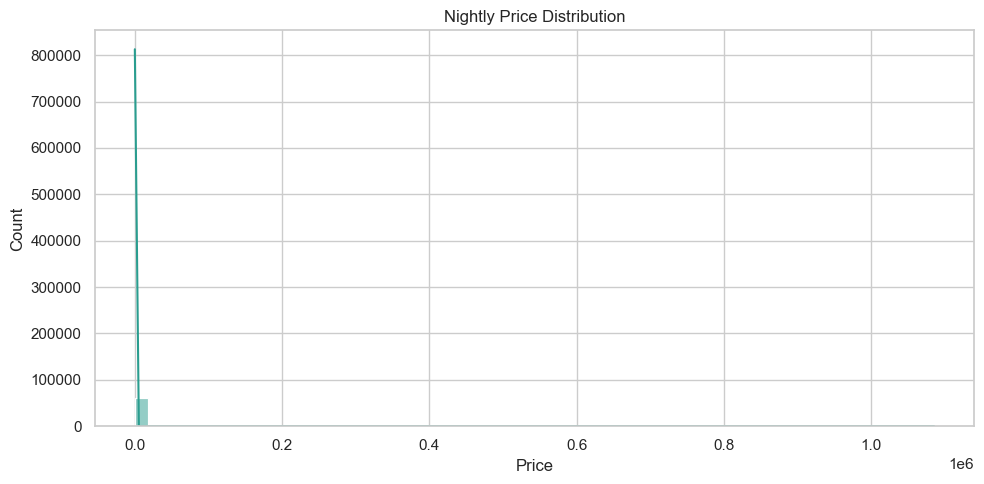

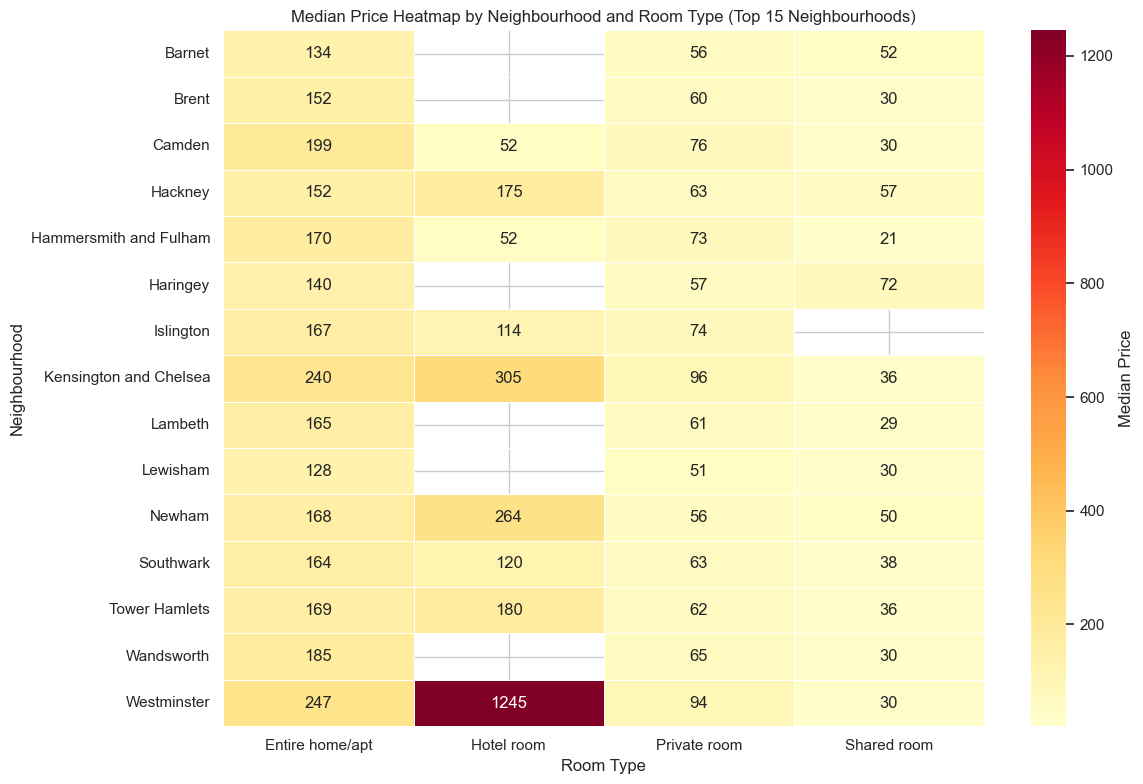

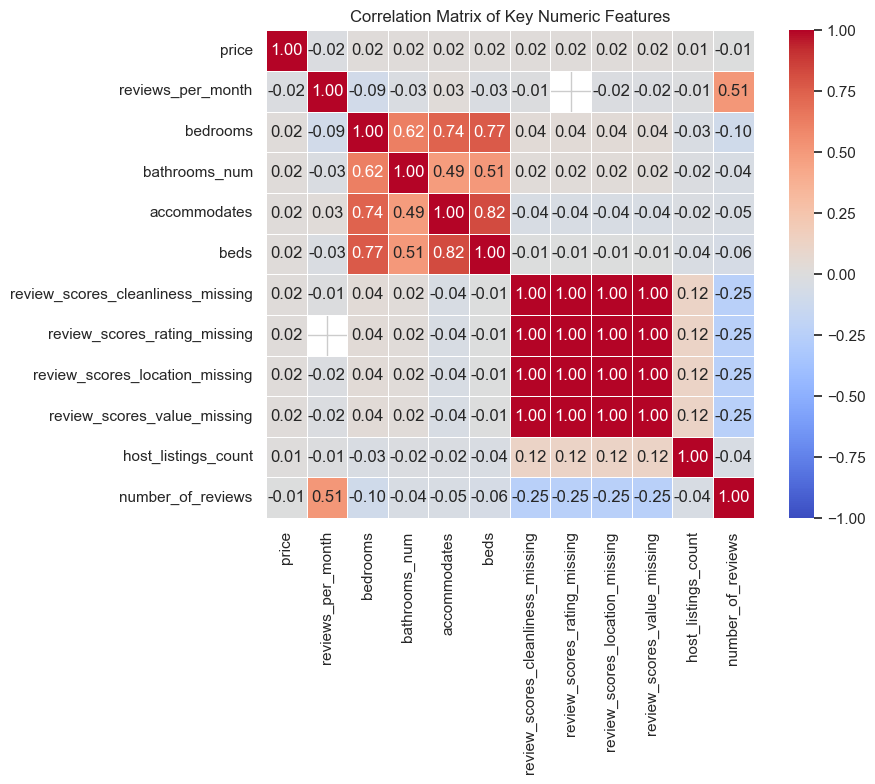

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use model_df if available; otherwise fall back to train_df or the raw df.
if "model_df" in globals():
    eda_df = model_df.copy()
elif "train_df" in globals():
    eda_df = train_df.copy()
elif "df" in globals():
    eda_df = df.copy()
else:
    raise NameError("No dataframe found. Please run the data loading/preparation cells first.")

# Ensure price is numeric for plotting and aggregation.
if "price" in eda_df.columns:
    eda_df["price"] = pd.to_numeric(
        eda_df["price"].astype(str).str.replace(r"[$,]", "", regex=True),
        errors="coerce",
    )

sns.set_theme(style="whitegrid", context="notebook")

# 1) Price distribution
if "price" not in eda_df.columns:
    print("Column 'price' is missing. Skipping price distribution plot.")
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        eda_df["price"].dropna(),
        bins=60,
        kde=True,
        color="#2A9D8F",
        edgecolor=None,
    )
    plt.title("Nightly Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 2) Regional price heatmap (median price by neighbourhood x room type)
region_candidates = ["neighbourhood_cleansed", "neighbourhood", "neighbourhood_group_cleansed"]
region_col = next((c for c in region_candidates if c in eda_df.columns), None)
room_col = "room_type" if "room_type" in eda_df.columns else None

if region_col is None or room_col is None or "price" not in eda_df.columns:
    print("Required columns for regional heatmap are missing. Skipping heatmap.")
else:
    top_regions = (
        eda_df[region_col]
        .value_counts(dropna=True)
        .head(15)
        .index
    )

    heatmap_df = eda_df[eda_df[region_col].isin(top_regions)].copy()
    pivot = heatmap_df.pivot_table(
        index=region_col,
        columns=room_col,
        values="price",
        aggfunc="median",
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        annot=True,
        fmt=".0f",
        linewidths=0.4,
        cbar_kws={"label": "Median Price"},
    )
    plt.title("Median Price Heatmap by Neighbourhood and Room Type (Top 15 Neighbourhoods)")
    plt.xlabel("Room Type")
    plt.ylabel("Neighbourhood")
    plt.tight_layout()
    plt.show()

# 3) Correlation matrix (numeric features)
numeric_df = eda_df.select_dtypes(include=["number"]).copy()
if numeric_df.shape[1] < 2:
    print("Not enough numeric features to compute a correlation matrix.")
else:
    if "price" in numeric_df.columns:
        target_corr = numeric_df.corr()["price"].abs().sort_values(ascending=False)
        selected_cols = target_corr.head(12).index.tolist()
        corr_plot_df = numeric_df[selected_cols]
    else:
        corr_plot_df = numeric_df.iloc[:, :12]

    corr_matrix = corr_plot_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=0.4,
    )
    plt.title("Correlation Matrix of Key Numeric Features")
    plt.tight_layout()
    plt.show()

### Key EDA Insights

1. Price is right-skewed with a long premium tail, supporting robust training strategies.
2. Median prices differ strongly by neighbourhood-room-type combinations.
3. Linear correlations with price are generally weak, supporting tree-based modeling choices.

### SQL Aggregations and Filtering (pandasql)

This section uses SQL-style queries for neighbourhood summaries, room-type structure, price segmentation, and host portfolio patterns.

In [5]:
# Install pandasql if not already available
try:
    import pandasql
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "pandasql"])
    import pandasql

from pandasql import sqldf

# Prepare data for SQL queries
listings_sql = df[["id", "neighbourhood_cleansed", "room_type", "property_type", "price", 
                   "bedrooms", "bathrooms", "accommodates", "review_scores_rating", 
                   "number_of_reviews", "host_id", "host_listings_count"]].copy()
listings_sql.columns = ["listing_id", "neighbourhood", "room_type", "property_type", "price", 
                        "bedrooms", "bathrooms", "accommodates", "review_score", 
                        "num_reviews", "host_id", "host_listing_count"]

# Ensure price is numeric
listings_sql["price"] = pd.to_numeric(
    listings_sql["price"].astype(str).str.replace(r"[$,]", "", regex=True),
    errors="coerce",
)

# Query 1: Neighbourhood-level summary statistics
q1 = """
SELECT
    neighbourhood,
    COUNT(*) AS num_listings,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(MIN(price), 2) AS min_price,
    ROUND(MAX(price), 2) AS max_price,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    SUM(CASE WHEN room_type = 'Entire home/apt' THEN 1 ELSE 0 END) AS entire_home_count,
    SUM(CASE WHEN room_type = 'Private room' THEN 1 ELSE 0 END) AS private_room_count,
    SUM(CASE WHEN room_type = 'Shared room' THEN 1 ELSE 0 END) AS shared_room_count
FROM listings_sql
WHERE neighbourhood IS NOT NULL
GROUP BY neighbourhood
ORDER BY num_listings DESC
LIMIT 15
"""

neighbourhood_summary = sqldf(q1, {"listings_sql": listings_sql})
print("\n=== Query 1: Top 15 Neighbourhoods by Listing Count ===")
display(neighbourhood_summary)

# Query 2: Room type analysis across London
q2 = """
SELECT
    room_type,
    COUNT(*) AS total_listings,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(MIN(price), 2) AS min_price,
    ROUND(MAX(price), 2) AS max_price,
    ROUND(AVG(bedrooms), 2) AS avg_bedrooms,
    ROUND(AVG(accommodates), 2) AS avg_accommodates,
    ROUND(AVG(review_score), 2) AS avg_review_score
FROM listings_sql
WHERE room_type IS NOT NULL AND price IS NOT NULL
GROUP BY room_type
ORDER BY total_listings DESC
"""

room_type_summary = sqldf(q2, {"listings_sql": listings_sql})
print("\n=== Query 2: Room Type Breakdown Across London ===")
display(room_type_summary)

# Query 3: Budget vs Premium segmentation (using quartiles)
q3 = """
SELECT
    CASE
        WHEN price <= 100 THEN 'Budget (<=100)'
        WHEN price <= 180 THEN 'Mid-range (101-180)'
        WHEN price <= 300 THEN 'Premium (181-300)'
        ELSE 'Luxury (>300)'
    END AS price_segment,
    COUNT(*) AS num_listings,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(bedrooms), 1) AS avg_bedrooms,
    ROUND(AVG(accommodates), 1) AS avg_accommodates,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    ROUND(AVG(host_listing_count), 1) AS avg_host_listings
FROM listings_sql
WHERE price IS NOT NULL
GROUP BY price_segment
ORDER BY avg_price
"""

price_segment = sqldf(q3, {"listings_sql": listings_sql})
print("\n=== Query 3: Price Segmentation Analysis ===")
display(price_segment)

# Query 4: Top hosts by number of listings
q4 = """
SELECT
    host_id,
    COUNT(*) AS num_listings,
    ROUND(AVG(price), 2) AS avg_price_per_listing,
    SUM(num_reviews) AS total_reviews_across_listings,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    ROUND(AVG(host_listing_count), 0) AS host_portfolio_size
FROM listings_sql
WHERE host_id IS NOT NULL AND price IS NOT NULL
GROUP BY host_id
HAVING COUNT(*) >= 5
ORDER BY num_listings DESC
LIMIT 10
"""

top_hosts = sqldf(q4, {"listings_sql": listings_sql})
print("\n=== Query 4: Top 10 Multi-Property Hosts (with 5+ listings) ===")
display(top_hosts)


=== Query 1: Top 15 Neighbourhoods by Listing Count ===


,neighbourhood,num_listings,avg_price,min_price,max_price,avg_review_score,entire_home_count,private_room_count,shared_room_count
0,Westminster,11385,342.14,13.00,"15,143.00",4.61,9158,2146,54
1,Tower Hamlets,7469,430.91,10.00,"1,085,147.00",4.63,4412,3040,15
2,Camden,6551,216.51,20.00,"15,000.00",4.62,4549,1965,30
3,Kensington and Chelsea,6401,336.07,24.00,"53,588.00",4.67,5439,924,11
4,Hackney,6359,161.13,25.00,"8,000.00",4.76,4118,2226,4
5,Southwark,5475,174.28,21.00,"10,001.00",4.70,3312,2150,9
6,Lambeth,5190,345.71,10.00,"66,189.00",4.74,3132,2051,7
7,Islington,5036,217.55,24.00,"74,100.00",4.70,3405,1627,1
8,Wandsworth,4965,198.43,16.00,"12,000.00",4.77,3272,1683,7
9,Hammersmith and Fulham,4157,199.19,11.00,"10,032.00",4.69,3004,1137,7



=== Query 2: Room Type Breakdown Across London ===


,room_type,total_listings,avg_price,min_price,max_price,avg_bedrooms,avg_accommodates,avg_review_score
0,Entire home/apt,42318,279.35,9.00,"1,085,147.00",1.77,4.24,4.66
1,Private room,19382,121.71,8.00,"66,189.00",1.07,1.93,4.69
2,Shared room,191,96.91,7.00,"1,800.00",1.07,4.06,4.19
3,Hotel room,72,657.83,19.00,"7,377.00",1.29,3.14,4.50



=== Query 3: Price Segmentation Analysis ===


,price_segment,num_listings,avg_price,avg_bedrooms,avg_accommodates,avg_review_score,avg_host_listings
0,Budget (<=100),22429,64.37,1.00,2.00,4.65,14.10
1,Mid-range (101-180),18308,138.30,1.40,3.50,4.67,32.30
2,Premium (181-300),12500,230.92,2.00,4.70,4.69,101.30
3,Luxury (>300),8726,846.22,2.50,5.60,4.70,236.80



=== Query 4: Top 10 Multi-Property Hosts (with 5+ listings) ===


,host_id,num_listings,avg_price_per_listing,total_reviews_across_listings,avg_review_score,host_portfolio_size
0,446820235,470,485.26,38,4.59,"5,469.00"
1,314162972,380,348.20,328,4.33,405.00
2,33889201,205,391.80,765,4.54,616.00
3,1432477,168,"1,289.29",1704,4.33,268.00
4,185324181,131,466.21,936,4.20,140.00
5,569524331,116,829.99,12,2.70,157.00
6,439074505,111,342.66,252,4.32,"1,481.00"
7,30253178,111,365.74,1224,4.43,127.00
8,156158778,110,879.18,213,4.89,225.00
9,228928499,108,135.66,1276,4.80,165.00


## Part 2: Model Training and Versioning

### Why six versions were tested and why deployment focuses on robust models

The modeling strategy was intentionally iterative because London prices are highly skewed and sensitive to outliers. A single model run could be misleading, so six versions were used to test both performance and stability:

1. **Version 1** establishes a baseline pipeline with Random Forest.
2. **Version 2** tests model alternatives and target transformation (`log1p`).
3. **Version 3** introduces tuning and cross-validation for robustness checks.
4. **Version 4** applies 99th-percentile capping to reduce extreme-value distortion.
5. **Version 5** tests LightGBM under the same capped-data protocol.
6. **Version 6** tests XGBoost for like-for-like comparison.

Deployment decision is based on three criteria together:
1. Lower RMSE
2. Higher R2
3. Lower cross-fold variance

The final recommendation is made in the V4-V6 comparison block below, where all models are evaluated under the same validation settings.

### Version 1: Baseline and Current Random Forest

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Target variable and features
X = train_df.drop(columns=["price"])
y = train_df["price"]

# Automatically detect numeric and categorical features
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Baseline: predict the median training price
baseline_model = DummyRegressor(strategy="median")
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_valid)

baseline_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_baseline))
baseline_r2 = r2_score(y_valid, y_pred_baseline)

# Random Forest model
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_valid)

rf_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
rf_r2 = r2_score(y_valid, y_pred_rf)

result_df = pd.DataFrame(
    {
        "model": ["Baseline (median)", "Random Forest"],
        "RMSE": [baseline_rmse, rf_rmse],
        "R2": [baseline_r2, rf_r2],
    }
)

print("Model evaluation results (validation set):")
display(result_df)

# Feature importance (based on Random Forest)
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Random Forest top 20 feature importances:")
display(feature_importance_df.head(20))

Number of numeric features: 22
Number of categorical features: 2
Model evaluation results (validation set):


,model,RMSE,R2
0,Baseline (median),"9,848.35",-0.00
1,Random Forest,"9,836.29",0.00


Random Forest top 20 feature importances:


,feature,importance
0,num__amenity_count,0.14
1,num__number_of_reviews,0.14
2,num__host_listings_count,0.14
3,num__review_scores_rating,0.13
4,num__maximum_nights,0.06
5,num__reviews_per_month,0.05
6,num__review_scores_cleanliness,0.05
7,num__review_scores_value,0.05
8,num__review_scores_location,0.04
9,num__accommodates,0.03


### Version 1 Notes

Version 1 is the executable baseline and reference point for all later improvements.

### Version 2: Model Comparison and Target Transformation

Compare Gradient Boosting and `log1p(price)` against the Version 1 baseline using the same split.

In [7]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Reuse X_train/X_valid/y_train/y_valid and preprocessor from Version 1
gbr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                random_state=42,
            ),
        ),
    ]
)

gbr_pipeline.fit(X_train, y_train)
y_pred_gbr = gbr_pipeline.predict(X_valid)

gbr_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_gbr))
gbr_r2 = r2_score(y_valid, y_pred_gbr)

rf_log_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=400,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_log_model = TransformedTargetRegressor(
    regressor=rf_log_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

rf_log_model.fit(X_train, y_train)
y_pred_rf_log = rf_log_model.predict(X_valid)

rf_log_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_rf_log))
rf_log_r2 = r2_score(y_valid, y_pred_rf_log)

improvement_df = pd.DataFrame(
    {
        "model": [
            "Random Forest (price)",
            "Gradient Boosting (price)",
            "Random Forest (log1p price)",
        ],
        "RMSE": [rf_rmse, gbr_rmse, rf_log_rmse],
        "R2": [rf_r2, gbr_r2, rf_log_r2],
    }
).sort_values("RMSE")

print("Improvement experiment results (validation set):")
display(improvement_df)

best_model_name = improvement_df.iloc[0]["model"]
best_rmse = improvement_df.iloc[0]["RMSE"]
best_r2 = improvement_df.iloc[0]["R2"]

print(f"Current best model: {best_model_name}")
print(f"Metrics: RMSE={best_rmse:.2f}, R2={best_r2:.3f}")

Improvement experiment results (validation set):


,model,RMSE,R2
0,Random Forest (price),"9,836.29",0.00
1,Gradient Boosting (price),"9,840.37",0.00
2,Random Forest (log1p price),"9,844.91",0.00


Current best model: Random Forest (price)
Metrics: RMSE=9836.29, R2=0.002


### Version 2 Notes

Version 2 checks whether model substitution or target transformation yields meaningful gains.

### Version 3: Hyperparameter Tuning and Cross-Validation

Run `RandomizedSearchCV` and then evaluate fold-level stability with 3-fold CV.

In [8]:
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate

rf_tune_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 12, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8],
}

search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y)

best_rf_pipeline = search.best_estimator_

print("Best parameters:")
print(search.best_params_)
print(f"Best tuned CV RMSE: {-search.best_score_:.2f}")

cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_validate(
    best_rf_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

cv_result_df = pd.DataFrame(
    {
        "fold": [1, 2, 3],
        "RMSE": -cv_scores["test_rmse"],
        "R2": cv_scores["test_r2"],
    }
)

cv_summary_df = pd.DataFrame(
    {
        "metric": ["RMSE", "R2"],
        "mean": [cv_result_df["RMSE"].mean(), cv_result_df["R2"].mean()],
        "std": [cv_result_df["RMSE"].std(), cv_result_df["R2"].std()],
    }
)

print("\n3-fold cross-validation results (by fold):")
display(cv_result_df)

print("\n3-fold cross-validation results (mean +/- std):")
display(cv_summary_df)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Best tuned CV RMSE: 3106.34

3-fold cross-validation results (by fold):


,fold,RMSE,R2
0,1,"7,653.40",0.00
1,2,928.75,-0.67
2,3,884.46,-0.15



3-fold cross-validation results (mean +/- std):


,metric,mean,std
0,RMSE,"3,155.54","3,895.33"
1,R2,-0.27,0.36


### Version 3 Notes

Version 3 focuses on whether tuned performance is stable across folds, not just locally optimal.

### Version 4: Extreme-Value Robustness Check

Apply 99th-percentile capping and re-run 3-fold validation using tuned Random Forest settings.

In [9]:
price_cap = y.quantile(0.99)
mask_capped = y <= price_cap

X_capped = X.loc[mask_capped].copy()
y_capped = y.loc[mask_capped].copy()

rf_best_params_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_split=5,
                min_samples_leaf=4,
                max_features="sqrt",
                max_depth=30,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

cv_capped = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_capped = cross_validate(
    rf_best_params_pipeline,
    X_capped,
    y_capped,
    cv=cv_capped,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

cv_capped_df = pd.DataFrame(
    {
        "fold": [1, 2, 3],
        "RMSE": -cv_scores_capped["test_rmse"],
        "R2": cv_scores_capped["test_r2"],
    }
)

cv_capped_summary = pd.DataFrame(
    {
        "metric": ["RMSE", "R2"],
        "mean": [cv_capped_df["RMSE"].mean(), cv_capped_df["R2"].mean()],
        "std": [cv_capped_df["RMSE"].std(), cv_capped_df["R2"].std()],
    }
)

print(f"Price cap at 99th percentile: {price_cap:,.2f}")
print(f"Samples after capping: {len(y_capped):,} / {len(y):,}")

print("\n3-fold cross-validation after capping (by fold):")
display(cv_capped_df)

print("\n3-fold cross-validation after capping (mean +/- std):")
display(cv_capped_summary)

Price cap at 99th percentile: 1,100.00
Samples after capping: 60,471 / 61,074

3-fold cross-validation after capping (by fold):


,fold,RMSE,R2
0,1,94.98,0.60
1,2,96.85,0.60
2,3,92.45,0.61



3-fold cross-validation after capping (mean +/- std):


,metric,mean,std
0,RMSE,94.76,2.21
1,R2,0.60,0.01


### Version 4 Notes

Version 4 verifies whether controlling extreme prices improves both accuracy and stability.

### Version 5: LightGBM Tuning and Cross-Validation

Train and tune LightGBM on capped data using the same CV protocol for fair comparison.

In [10]:
import importlib
import subprocess
import sys

from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate

# Ensure LightGBM is available in the current kernel environment.
try:
    lightgbm_module = importlib.import_module("lightgbm")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    lightgbm_module = importlib.import_module("lightgbm")

LGBMRegressor = lightgbm_module.LGBMRegressor

lgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LGBMRegressor(random_state=42, n_jobs=-1)),
    ]
)

lgb_param_distributions = {
    "model__n_estimators": [100, 150, 200, 250, 300, 350, 400, 450, 500],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "model__num_leaves": [20, 25, 30, 35, 40, 45, 50, 55, 60],
    "model__max_depth": [5, 7, 9, 11, 13, 15],
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=lgb_param_distributions,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

lgb_search.fit(X_capped, y_capped)
best_lgb_pipeline = lgb_search.best_estimator_

print("Best LightGBM parameters:")
print(lgb_search.best_params_)
print(f"Best LightGBM tuned CV RMSE: {-lgb_search.best_score_:.2f}")

cv_lgb = KFold(n_splits=3, shuffle=True, random_state=42)
lgb_cv_scores = cross_validate(
    best_lgb_pipeline,
    X_capped,
    y_capped,
    cv=cv_lgb,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

lgb_cv_df = pd.DataFrame(
    {
        "fold": [1, 2, 3],
        "RMSE": -lgb_cv_scores["test_rmse"],
        "R2": lgb_cv_scores["test_r2"],
    }
)

lgb_cv_summary = pd.DataFrame(
    {
        "metric": ["RMSE", "R2"],
        "mean": [lgb_cv_df["RMSE"].mean(), lgb_cv_df["R2"].mean()],
        "std": [lgb_cv_df["RMSE"].std(), lgb_cv_df["R2"].std()],
    }
)

print("\nLightGBM 3-fold cross-validation results (by fold):")
display(lgb_cv_df)

print("\nLightGBM 3-fold cross-validation results (mean +/- std):")
display(lgb_cv_summary)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1923
[LightGBM] [Info] Number of data points in the train set: 60471, number of used features: 59
[LightGBM] [Info] Start training from score 174.872799
Best LightGBM parameters:
{'model__num_leaves': 55, 'model__n_estimators': 500, 'model__max_depth': 11, 'model__learning_rate': 0.03}
Best LightGBM tuned CV RMSE: 98.37

LightGBM 3-fold cross-validation results (by fold):


,fold,RMSE,R2
0,1,89.50,0.65
1,2,91.00,0.64
2,3,87.23,0.65



LightGBM 3-fold cross-validation results (mean +/- std):


,metric,mean,std
0,RMSE,89.24,1.90
1,R2,0.65,0.01


### Version 5 Notes

Version 5 tests whether boosting methods improve predictive power without sacrificing stability.

### Version 6: XGBoost Tuning and Cross-Validation

Evaluate XGBoost under the same capped-data and CV settings used in Version 5.

In [11]:
import importlib
import subprocess
import sys

from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate

# Ensure XGBoost is available in the current kernel environment.
try:
    xgboost_module = importlib.import_module("xgboost")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    xgboost_module = importlib.import_module("xgboost")

XGBRegressor = xgboost_module.XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            XGBRegressor(
                random_state=42,
                n_jobs=-1,
                objective="reg:squarederror",
            ),
        ),
    ]
)

xgb_param_distributions = {
    "model__n_estimators": [100, 150, 200, 250, 300, 350, 400, 450, 500],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [4, 5, 6, 7, 8, 10],
    "model__min_child_weight": [1, 2, 3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_capped, y_capped)
best_xgb_pipeline = xgb_search.best_estimator_

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print(f"Best XGBoost tuned CV RMSE: {-xgb_search.best_score_:.2f}")

cv_xgb = KFold(n_splits=3, shuffle=True, random_state=42)
xgb_cv_scores = cross_validate(
    best_xgb_pipeline,
    X_capped,
    y_capped,
    cv=cv_xgb,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

xgb_cv_df = pd.DataFrame(
    {
        "fold": [1, 2, 3],
        "RMSE": -xgb_cv_scores["test_rmse"],
        "R2": xgb_cv_scores["test_r2"],
    }
)

xgb_cv_summary = pd.DataFrame(
    {
        "metric": ["RMSE", "R2"],
        "mean": [xgb_cv_df["RMSE"].mean(), xgb_cv_df["R2"].mean()],
        "std": [xgb_cv_df["RMSE"].std(), xgb_cv_df["R2"].std()],
    }
)

print("\nXGBoost 3-fold cross-validation results (by fold):")
display(xgb_cv_df)

print("\nXGBoost 3-fold cross-validation results (mean +/- std):")
display(xgb_cv_summary)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost parameters:
{'model__subsample': 1.0, 'model__n_estimators': 350, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.8}
Best XGBoost tuned CV RMSE: 98.12

XGBoost 3-fold cross-validation results (by fold):


,fold,RMSE,R2
0,1,88.83,0.65
1,2,90.49,0.65
2,3,86.53,0.66



XGBoost 3-fold cross-validation results (mean +/- std):


,metric,mean,std
0,RMSE,88.62,1.99
1,R2,0.65,0.01


### Version 6 Notes

Version 6 provides a third strong candidate and is judged jointly by RMSE, R2, and fold stability.

### Version 4 to Version 6 Comparison

This block compares Random Forest (v4), LightGBM (v5), and XGBoost (v6) under the same capped-data protocol and ranking rule.

In [12]:
required_vars = [
    "cv_capped_df",
    "cv_capped_summary",
    "lgb_cv_df",
    "lgb_cv_summary",
    "xgb_cv_df",
    "xgb_cv_summary",
]

missing_required = [name for name in required_vars if name not in globals()]
if missing_required:
    raise NameError(
        "Missing required results for comparison: " + ", ".join(missing_required)
    )

model_fold_compare_df = pd.concat(
    [
        cv_capped_df.assign(model="Random Forest (v4)"),
        lgb_cv_df.assign(model="LightGBM (v5)"),
        xgb_cv_df.assign(model="XGBoost (v6)"),
    ],
    ignore_index=True,
)

summary_rf = cv_capped_summary.set_index("metric")
summary_lgb = lgb_cv_summary.set_index("metric")
summary_xgb = xgb_cv_summary.set_index("metric")

model_compare_summary_df = pd.DataFrame(
    {
        "model": ["Random Forest (v4)", "LightGBM (v5)", "XGBoost (v6)"],
        "RMSE_mean": [
            float(summary_rf.loc["RMSE", "mean"]),
            float(summary_lgb.loc["RMSE", "mean"]),
            float(summary_xgb.loc["RMSE", "mean"]),
        ],
        "RMSE_std": [
            float(summary_rf.loc["RMSE", "std"]),
            float(summary_lgb.loc["RMSE", "std"]),
            float(summary_xgb.loc["RMSE", "std"]),
        ],
        "R2_mean": [
            float(summary_rf.loc["R2", "mean"]),
            float(summary_lgb.loc["R2", "mean"]),
            float(summary_xgb.loc["R2", "mean"]),
        ],
        "R2_std": [
            float(summary_rf.loc["R2", "std"]),
            float(summary_lgb.loc["R2", "std"]),
            float(summary_xgb.loc["R2", "std"]),
        ],
    }
)

model_compare_summary_df = model_compare_summary_df.sort_values(
    by=["RMSE_mean", "R2_mean", "RMSE_std"],
    ascending=[True, False, True],
).reset_index(drop=True)

best_model_row = model_compare_summary_df.iloc[0]
best_model_name = best_model_row["model"]

print("Three-model fold-level comparison:")
display(model_fold_compare_df)

print("\nThree-model summary comparison (sorted by RMSE first, R2 second, stability as tie-breaker):")
display(model_compare_summary_df)

print("\nRecommended primary model:")
print(
    f"{best_model_name} | "
    f"RMSE={best_model_row['RMSE_mean']:.2f} (std={best_model_row['RMSE_std']:.2f}), "
    f"R2={best_model_row['R2_mean']:.3f} (std={best_model_row['R2_std']:.3f})"
)

print("\nCurrent deployment recommendation:")
if best_model_name == "XGBoost (v6)":
    print("XGBoost has the best metrics, but LightGBM remains the default primary model for this round as requested; XGBoost is kept as the backup.")
elif best_model_name == "LightGBM (v5)":
    print("LightGBM remains the best model; keep the current primary model setup.")
else:
    print("Random Forest is best in this run; verify environment and parameters before finalizing.")

Three-model fold-level comparison:


,fold,RMSE,R2,model
0,1,94.98,0.60,Random Forest (v4)
1,2,96.85,0.60,Random Forest (v4)
2,3,92.45,0.61,Random Forest (v4)
3,1,89.50,0.65,LightGBM (v5)
4,2,91.00,0.64,LightGBM (v5)
5,3,87.23,0.65,LightGBM (v5)
6,1,88.83,0.65,XGBoost (v6)
7,2,90.49,0.65,XGBoost (v6)
8,3,86.53,0.66,XGBoost (v6)



Three-model summary comparison (sorted by RMSE first, R2 second, stability as tie-breaker):


,model,RMSE_mean,RMSE_std,R2_mean,R2_std
0,XGBoost (v6),88.62,1.99,0.65,0.01
1,LightGBM (v5),89.24,1.90,0.65,0.01
2,Random Forest (v4),94.76,2.21,0.60,0.01



Recommended primary model:
XGBoost (v6) | RMSE=88.62 (std=1.99), R2=0.653 (std=0.007)

Current deployment recommendation:
XGBoost has the best metrics, but LightGBM remains the default primary model for this round as requested; XGBoost is kept as the backup.


## Part 3: Model Export Artifacts

This section exports the trained pipelines and metadata for app inference and model comparison.

Generated artifacts include Random Forest, LightGBM, and XGBoost model files plus metadata JSON files.

In [15]:
import json
from pathlib import Path

import joblib
import numpy as np
from sklearn.base import clone

artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Prefer the final robust model from Version 4 when available.
if "rf_best_params_pipeline" in globals():
    deploy_pipeline = clone(rf_best_params_pipeline)
    deploy_model_name = "rf_best_params_pipeline"
elif "best_rf_pipeline" in globals():
    deploy_pipeline = clone(best_rf_pipeline)
    deploy_model_name = "best_rf_pipeline"
elif "rf_pipeline" in globals():
    deploy_pipeline = clone(rf_pipeline)
    deploy_model_name = "rf_pipeline"
else:
    raise NameError(
        "No trained Random Forest pipeline found. "
        "Run model training cells first (Version 1/3/4)."
    )

# Prefer capped training data (Version 4) when available.
if "X_capped" in globals() and "y_capped" in globals():
    X_deploy = X_capped.copy()
    y_deploy = y_capped.copy()
    training_scope = "capped_99pct"
elif "X" in globals() and "y" in globals():
    X_deploy = X.copy()
    y_deploy = y.copy()
    training_scope = "full_data"
else:
    raise NameError(
        "Training data not found. Run earlier modeling cells to create X/y (and X_capped/y_capped if using Version 4)."
    )

# Fit on deployment data so app inference matches the final training scope.
deploy_pipeline.fit(X_deploy, y_deploy)
train_pred = deploy_pipeline.predict(X_deploy)
residuals = y_deploy.to_numpy() - train_pred

feature_columns = X_deploy.columns.tolist()
default_values = {}
for col in feature_columns:
    series = X_deploy[col]
    non_null = series.dropna()

    if non_null.empty:
        default_values[col] = 0.0
        continue

    try:
        is_numeric = np.issubdtype(non_null.dtype, np.number)
    except TypeError:
        is_numeric = False

    if is_numeric:
        default_values[col] = float(non_null.median())
    else:
        mode_series = non_null.mode(dropna=True)
        default_values[col] = str(mode_series.iloc[0]) if not mode_series.empty else "Unknown"

metadata = {
    "model_name": deploy_model_name,
    "target": "price",
    "feature_columns": feature_columns,
    "default_values": default_values,
    "residual_std": float(np.std(residuals)),
    "residual_q05": float(np.quantile(residuals, 0.05)),
    "residual_q95": float(np.quantile(residuals, 0.95)),
    "n_training_samples": int(len(X_deploy)),
    "training_scope": training_scope,
    "price_cap_99": float(price_cap) if "price_cap" in globals() else None,
}

model_path = artifact_dir / "rf_price_model.joblib"
meta_path = artifact_dir / "model_metadata.json"

joblib.dump(deploy_pipeline, model_path)
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=True, indent=2)

print(f"Saved model artifact: {model_path.resolve()}")
print(f"Saved metadata: {meta_path.resolve()}")
print(f"Model: {deploy_model_name}")
print(f"Training scope: {training_scope}")
print(f"Training samples: {metadata['n_training_samples']:,}")
print(f"Residual std: {metadata['residual_std']:.2f}")

Saved model artifact: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\rf_price_model.joblib
Saved metadata: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\model_metadata.json
Model: rf_best_params_pipeline
Training scope: capped_99pct
Training samples: 60,471
Residual std: 77.99


### Export LightGBM Model Artifact

Save the best Version 5 LightGBM pipeline and metadata for inference.

In [18]:
import json
from pathlib import Path

import joblib
import numpy as np

if "best_lgb_pipeline" not in globals():
    raise NameError(
        "best_lgb_pipeline not found. Please run the Version 5 LightGBM training cell first."
    )

if "X_capped" not in globals() or "y_capped" not in globals():
    raise NameError("X_capped/y_capped not found. Please run the Version 4 cell first.")

artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Refit on capped data so exported artifacts match the final training scope.
best_lgb_pipeline.fit(X_capped, y_capped)
lgb_train_pred = best_lgb_pipeline.predict(X_capped)
lgb_residuals = y_capped.to_numpy() - lgb_train_pred

feature_columns = X_capped.columns.tolist()
default_values = {}
for col in feature_columns:
    series = X_capped[col]
    non_null = series.dropna()

    if non_null.empty:
        default_values[col] = 0.0
        continue

    try:
        is_numeric = np.issubdtype(non_null.dtype, np.number)
    except TypeError:
        is_numeric = False

    if is_numeric:
        default_values[col] = float(non_null.median())
    else:
        mode_series = non_null.mode(dropna=True)
        default_values[col] = str(mode_series.iloc[0]) if not mode_series.empty else "Unknown"

lgb_metadata = {
    "model_name": "best_lgb_pipeline",
    "target": "price",
    "feature_columns": feature_columns,
    "default_values": default_values,
    "residual_std": float(np.std(lgb_residuals)),
    "residual_q05": float(np.quantile(lgb_residuals, 0.05)),
    "residual_q95": float(np.quantile(lgb_residuals, 0.95)),
    "n_training_samples": int(len(X_capped)),
    "training_scope": "capped_99pct",
    "price_cap_99": float(price_cap) if "price_cap" in globals() else None,
}

lgb_model_path = artifact_dir / "lgb_price_model.joblib"
lgb_meta_path = artifact_dir / "lgb_model_metadata.json"

joblib.dump(best_lgb_pipeline, lgb_model_path)
with open(lgb_meta_path, "w", encoding="utf-8") as f:
    json.dump(lgb_metadata, f, ensure_ascii=True, indent=2)

print(f"Saved LightGBM model artifact: {lgb_model_path.resolve()}")
print(f"Saved LightGBM metadata: {lgb_meta_path.resolve()}")
print(f"Training samples: {lgb_metadata['n_training_samples']:,}")
print(f"Residual std: {lgb_metadata['residual_std']:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1923
[LightGBM] [Info] Number of data points in the train set: 60471, number of used features: 59
[LightGBM] [Info] Start training from score 174.872799


c:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Saved LightGBM model artifact: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\lgb_price_model.joblib
Saved LightGBM metadata: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\lgb_model_metadata.json
Training samples: 60,471
Residual std: 78.25


### Export XGBoost Model Artifact

Save the best Version 6 XGBoost pipeline and metadata as an alternative deployment candidate.

In [21]:
import json
from pathlib import Path

import joblib
import numpy as np

if "best_xgb_pipeline" not in globals():
    raise NameError(
        "best_xgb_pipeline not found. Please run the Version 6 XGBoost training cell first."
    )

if "X_capped" not in globals() or "y_capped" not in globals():
    raise NameError("X_capped/y_capped not found. Please run the Version 4 cell first.")

artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Refit on capped data so exported artifacts match the final training scope.
best_xgb_pipeline.fit(X_capped, y_capped)
xgb_train_pred = best_xgb_pipeline.predict(X_capped)
xgb_residuals = y_capped.to_numpy() - xgb_train_pred

feature_columns = X_capped.columns.tolist()
default_values = {}
for col in feature_columns:
    series = X_capped[col]
    non_null = series.dropna()

    if non_null.empty:
        default_values[col] = 0.0
        continue

    try:
        is_numeric = np.issubdtype(non_null.dtype, np.number)
    except TypeError:
        is_numeric = False

    if is_numeric:
        default_values[col] = float(non_null.median())
    else:
        mode_series = non_null.mode(dropna=True)
        default_values[col] = str(mode_series.iloc[0]) if not mode_series.empty else "Unknown"

xgb_metadata = {
    "model_name": "best_xgb_pipeline",
    "target": "price",
    "feature_columns": feature_columns,
    "default_values": default_values,
    "residual_std": float(np.std(xgb_residuals)),
    "residual_q05": float(np.quantile(xgb_residuals, 0.05)),
    "residual_q95": float(np.quantile(xgb_residuals, 0.95)),
    "n_training_samples": int(len(X_capped)),
    "training_scope": "capped_99pct",
    "price_cap_99": float(price_cap) if "price_cap" in globals() else None,
}

xgb_model_path = artifact_dir / "xgb_price_model.joblib"
xgb_meta_path = artifact_dir / "xgb_model_metadata.json"

joblib.dump(best_xgb_pipeline, xgb_model_path)
with open(xgb_meta_path, "w", encoding="utf-8") as f:
    json.dump(xgb_metadata, f, ensure_ascii=True, indent=2)

print(f"Saved XGBoost model artifact: {xgb_model_path.resolve()}")
print(f"Saved XGBoost metadata: {xgb_meta_path.resolve()}")
print(f"Training samples: {xgb_metadata['n_training_samples']:,}")
print(f"Residual std: {xgb_metadata['residual_std']:.2f}")

Saved XGBoost model artifact: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\xgb_price_model.joblib
Saved XGBoost metadata: C:\Users\YUSU\OneDrive\LBS\Term2\Data Python ML\group\artifacts\xgb_model_metadata.json
Training samples: 60,471
Residual std: 67.91
